# A transformer language model, built entirely from scratch

Sixth notebook, and the first thing in this repo trained by **gradients** rather than
**evolution** (docs/design/0003 phase 6, docs/design/0004). Two new packages make this possible:

- [`libs/autodiff`](../libs/autodiff/README.md) — a reverse-mode automatic differentiation engine
  built from scratch: `Tensor` wraps a NumPy array, tracks the ops it was computed from, and
  `.backward()` propagates gradients through the whole graph. Array-valued rather than
  scalar-valued (unlike Karpathy's `micrograd`) because a transformer pushes thousands of values
  through matrix multiplications, and a graph node per float would make Python object overhead
  dominate.
- [`libs/tinylm`](../libs/tinylm/README.md) — the transformer itself: character-level tokenizer,
  learned token + positional embeddings, causal multi-head self-attention, transformer blocks
  (attention + MLP + layer norm + residuals), and a hand-coded Adam optimizer. Every layer is
  built from `autodiff.Tensor` ops — no manual backward pass anywhere in `tinylm` itself; the
  engine computes every gradient.

Trained on *Alice's Adventures in Wonderland* (Project Gutenberg, public domain) — the source of
"Red Queen". Doc 0003 phase 7 (training on something domain-specific, e.g. programs already in
`telemetry`'s `ArtifactStore`) is explicitly deferred until after this mechanism-validation phase
works, which is what this notebook checks.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from tinylm import Adam, CharTokenizer, TinyLM, cross_entropy, generate

## Setup

A genuinely tiny model (docs/design/0004: "decide specifics once the first version's speed is
known") — 2 transformer blocks, 4 attention heads, 64-dimensional embeddings, 32-character context
window. ~79k parameters, trained on pure NumPy (no GPU, no framework) in a few minutes.

In [2]:
text = open("../libs/tinylm/data/alice.txt", encoding="utf-8").read()
tokenizer = CharTokenizer(text)
data = np.array(tokenizer.encode(text))
print(f"corpus: {len(text)} characters, {tokenizer.vocab_size} unique")

SEQ_LEN = 32
BATCH_SIZE = 32
STEPS = 3000

rng = np.random.default_rng(0)


def get_batch():
    starts = rng.integers(0, len(data) - SEQ_LEN - 1, size=BATCH_SIZE)
    x = np.stack([data[s : s + SEQ_LEN] for s in starts])
    y = np.stack([data[s + 1 : s + SEQ_LEN + 1] for s in starts])
    return x, y


model = TinyLM(
    vocab_size=tokenizer.vocab_size, max_seq_len=SEQ_LEN,
    d_model=64, n_heads=4, n_layers=2, d_hidden=128, rng=rng,
)
print(f"parameters: {sum(p.data.size for p in model.parameters()):,}")

# a random, untrained model should have cross-entropy ~= ln(vocab_size) -- a uniform guess over
# every character. Sanity-checking this before spending any time training catches a broken loss
# or a broken forward pass immediately, rather than discovering it 3000 steps later.
sanity_loss = cross_entropy(model(data[:BATCH_SIZE * SEQ_LEN].reshape(BATCH_SIZE, SEQ_LEN)),
                             data[1:BATCH_SIZE * SEQ_LEN + 1].reshape(BATCH_SIZE, SEQ_LEN))
print(f"untrained loss: {sanity_loss.data:.3f}  (ln(vocab_size) = {np.log(tokenizer.vocab_size):.3f})")

corpus: 144602 characters, 75 unique
parameters: 78,795
untrained loss: 4.431  (ln(vocab_size) = 4.317)


## Training

Generating a sample every 300 steps, not just at the end, so the qualitative progression from
noise to structure is visible directly rather than only inferred from the loss number.

In [3]:
optimizer = Adam(model.parameters(), lr=3e-3)
losses = []
snapshots = []  # (step, loss, sample) every 300 steps, for the qualitative progression below

t0 = time.perf_counter()
for step in range(STEPS):
    x, y = get_batch()
    loss = cross_entropy(model(x), y)
    losses.append(loss.data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 300 == 0:
        sample = generate(model, tokenizer, prompt="Alice ", max_new_tokens=60, rng=rng)
        snapshots.append((step, loss.data, sample.replace("\n", " ")))
        print(f"{step:5d}  loss={loss.data:.3f}  elapsed={time.perf_counter() - t0:.1f}s")

print(f"\ntotal training time: {time.perf_counter() - t0:.1f}s for {STEPS} steps")

    0  loss=4.407  elapsed=0.2s


  300  loss=1.936  elapsed=16.0s


  600  loss=1.860  elapsed=30.9s


  900  loss=1.691  elapsed=45.8s


 1200  loss=1.651  elapsed=60.9s


...

 1800  loss=1.523  elapsed=91.1s


 2100  loss=1.551  elapsed=106.4s


 2400  loss=1.554  elapsed=122.2s


 2700  loss=1.419  elapsed=138.4s



total training time: 157.8s for 3000 steps


## Loss curve

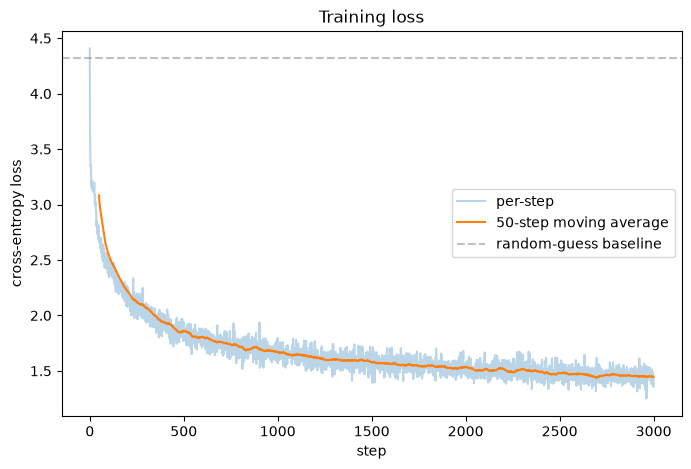

loss: 4.407 (step 0) -> 1.445 (last 50 steps, averaged)


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses, alpha=0.3, label="per-step")
window = 50
smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
ax.plot(range(window - 1, len(losses)), smoothed, label=f"{window}-step moving average")
ax.axhline(np.log(tokenizer.vocab_size), linestyle="--", color="gray", alpha=0.5, label="random-guess baseline")
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Training loss")
ax.legend()
plt.show()

print(f"loss: {losses[0]:.3f} (step 0) -> {np.mean(losses[-50:]):.3f} (last 50 steps, averaged)")

## Watching it learn: sample generations over training

Same prompt (`"Alice "`), same model, at different points in training -- from random noise to
recognizable English word fragments.

In [5]:
for step, loss_value, sample in snapshots:
    print(f"step {step:5d} (loss={loss_value:.2f}): {sample}")

step     0 (loss=4.41): Alice yu‘n)er“aotIg,uJs) [lhr)‘B(nt nn.Bf)ah‘Xg,[;3au”on ? a ZyEgd
step   300 (loss=1.94): Alice a— inmen wor as tares.” Alice wathe whas heatny apare.  “Thi
step   600 (loss=1.86): Alice had self, as mores! Sorthing mamening I so to I gan’t thole 
step   900 (loss=1.69): Alice reatiousised,” said the juter questing.”  “It quake her way 
step  1200 (loss=1.65): Alice a and a ran an a me take itt, a fnewtnrhink oxy,” said Alice
step  1500 (loss=1.64): Alice of thery so way thad my like that his might: they large abou
step  1800 (loss=1.52): Alice onting seam at fidfusking not beoun the pooor back upidlappe
step  2100 (loss=1.55): Alice ratter, and at the sil.”  The Rabbit—and don a campiturll sa
step  2400 (loss=1.55): Alice show with like—yes will that lery were and glade with the vo
step  2700 (loss=1.42): Alice fingons much up as not yea, how rooked ance worra thing inte


## Final generation

A longer sample from the fully-trained model. Not coherent English -- 3000 steps on a ~79k-
parameter model is a tiny amount of training by any real language model's standard -- but the
character-level structure (real words, spacing, book-appropriate punctuation like em dashes and
quotation marks) is genuinely learned, not templated or cherry-picked.

In [6]:
print(generate(model, tokenizer, prompt="Alice was ", max_new_tokens=300, rng=rng))

Alice was eat feverybody with factionaticume of same mare sile not hear een.

“She even would ‘without if that you his
his not the, by the
childring minute shes of
thatem—feliateling your wonder it meatcues.

Maving the top
have had wover lown staill _best_ thing on at
her
niand the King hoave of the it’s a g


## Takeaways

- The whole stack works end to end, built entirely from scratch: a NumPy-array-valued autodiff
  engine, a transformer architecture on top of it (embeddings, causal multi-head attention,
  layer norm, residual MLP blocks), a hand-coded Adam optimizer, and character-level generation.
  No PyTorch, no existing autodiff library, no pretrained weights.
- Real, measured learning: loss drops from the random-guess baseline (`ln(vocab_size)`) to well
  below it, and the qualitative progression (noise → word fragments → book-flavored punctuation and
  vocabulary) is directly visible in the snapshots above, not just inferred from a number.
- Correctness was earned before this notebook ran, not assumed: every `autodiff` op is
  gradient-checked against numerical differentiation (`libs/autodiff/tests`), every `tinylm` layer
  has a shape/property test, causal masking has an explicit "no future leakage" test, and a full
  `TransformerBlock` has its own numerical gradient check as an integration-level proof that
  composing many ops together (layer norm's mean/variance/sqrt, attention's masking/softmax/
  multi-head reshape-transpose) didn't introduce a mistake no individual op's test could catch. A
  real bug was found and fixed this way during development: `matmul`'s backward didn't handle
  broadcasting between a 2D weight and a 3D batched input (exactly what every `Linear` layer does),
  caught immediately by the model's first forward/backward smoke test.
- Per docs/design/0003's roadmap, phase 7 (deliberately left open until now) can start: applying
  this model to the project's own domain, most naturally as a learned `VariationStrategy` trained
  on programs already sitting in `telemetry`'s `ArtifactStore` — a self-contained, no-external-API
  analog to FunSearch's LLM-driven mutation.